In [83]:
# 03_model_training.ipynb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
import os

In [84]:
#from google.colab import drive
#drive.mount('/content/drive')

In [85]:
# 載入處理後數據
#processed_path = "/content/data/processed/elliptic_processed.pt" # google colab
processed_path = "../data/processed/elliptic_processed.pt" # local

data = torch.load(processed_path)   # load processed data
x = data['x']                       # node features
edge_index = data['edge_index']     # edge_index 是一個 [2, num_edges] 的 tensor，表示圖的邊
y = data['y']                       # node labels

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 將數據移動到 GPU（如果可用）
x = x.to(device)                    # PyTorch requires all operands in an operation to be on the same device.
edge_index = edge_index.to(device)  # edge_index 是圖的結構信息，通常不需要移動到 GPU，但如果你的模型需要在 GPU 上運行，最好將其移動到同一設備上以避免錯誤。
y = y.to(device)         

/var/folders/6p/f3bb7wps1p9crqh3cv0vjjfc0000gn/T/ipykernel_13940/2555404904.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(processed_path)   # load pr

In [86]:
# 拆分 train/val/test（只用有標記的）
labeled_mask = y != -1          # 1-D (or n-D) boolean or byte/int tensor,  e.g. tensor([False,  True, False,  True, False, ...])
labeled_indices = torch.where(labeled_mask)[0].cpu().numpy()      # array of indices where labeled_mask is True, 這裡得到的是有標記節點的索引列表，轉換為 numpy array 以便使用 sklearn 的 train_test_split 函數

# 第一次拆分：80% (train+val) 和 20% (test)
train_val_idx, test_idx = train_test_split(         
    labeled_indices,                            
    test_size=0.2,                              
    stratify=y[labeled_mask].cpu().numpy(),     
    random_state=42
)

# 第二次拆分：從 train_val 中再拆 80% train 和 20% val
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.2,
    stratify=y[train_val_idx].cpu().numpy(),
    random_state=42
)

train_idx = torch.tensor(train_idx, device=device)
val_idx = torch.tensor(val_idx, device=device)
test_idx = torch.tensor(test_idx, device=device)

print(f"訓練樣本: {len(train_idx)}, 驗證樣本: {len(val_idx)}, 測試樣本: {len(test_idx)}")
print(f"比例: Train {len(train_idx)/len(labeled_indices)*100:.1f}% | Val {len(val_idx)/len(labeled_indices)*100:.1f}% | Test {len(test_idx)/len(labeled_indices)*100:.1f}%")

print("\nFirst 10 training indices:")
print(train_idx[:10])  # 打印前 10 個訓練索引
print("First 10 validation indices:")
print(val_idx[:10])    # 打印前 10 個驗證索引
print("First 10 test indices:")
print(test_idx[:10])   # 打印前 10 個測試索引

訓練樣本: 29800, 驗證樣本: 7451, 測試樣本: 9313
比例: Train 64.0% | Val 16.0% | Test 20.0%

First 10 training indices:
tensor([168503,  27310, 176323,  33311,   1168, 103774,  98546, 184237,  30939,
        101820])
First 10 validation indices:
tensor([ 35851, 189995, 110155,   7971,   9422,  46372,  41195, 135407,  13046,
         79754])
First 10 test indices:
tensor([ 77168, 159961, 121767, 153673,  92481,  29262,  57238,  71116, 118996,
        144172])


In [87]:
# 定義 GraphSAGE 模型
class GraphSAGE(nn.Module):     # every modal in PyTorch should inherit from nn.Module
    def __init__(self, in_feats, hidden=128, num_layers=3):     # in_feats 是輸入特徵的維度，hidden 是隱藏層的維度，num_layers 是 GraphSAGE 層的數量
        super().__init__()                                  
        self.layers = nn.ModuleList()                       # (a list store model layer in order) 這裡用來存儲多層 GraphSAGE 層的列表，nn.ModuleList 是 PyTorch 提供的一種特殊的容器，用於存儲 nn.Module 的子模塊，這樣它們就會被正確地註冊並且在調用 model.parameters() 時能夠被包含在內
        self.layers.append(nn.Linear(in_feats, hidden))     # append 第一層 GraphSAGE 層到 ModuleList，將輸入特徵維度映射到隱藏層維度 feature: in_feats → hidden
        for _ in range(1, num_layers):                      #  從第二層開始，每層的輸入維度是前一層的輸出維度（hidden）加上聚合後的鄰居特徵維度（hidden），所以是 hidden * 2
            self.layers.append(nn.Linear(hidden * 2, hidden))  # append 後續的 GraphSAGE 層到 ModuleList，將前一層的輸出維度（hidden * 2）映射到隱藏層維度（hidden）
        self.classifier = nn.Linear(hidden, 2)  # Output layer: 正常/異常

    def forward(self, x, edge_index, idx=None):                                 
        h = x                                                                    # h = x = [N, in_feats], tensor of node features, N 是節點數量，in_feats 是每個節點的特徵維度
        for i, layer in enumerate(self.layers):                                               # 遍歷每一層 GraphSAGE 層，對 h 進行更新
            row, col = edge_index                                                # (row) = start, (col) = end, edge_index = [2, num_edges] 的 tensor
            num_neigh = torch.bincount(row, minlength=h.size(0)).float()         # counting out-degree of each node

            aggr = torch.zeros_like(h)                                           #  initialize a tensor size same as h ，用於存儲聚合後的鄰居特徵
            aggr.index_add_(dim=0, index=row, source=h[col])                     # 加到 aggr 的對應行上(第0行)，row 是 aggregate 的目標行索引，h[col] 是鄰居特徵
            aggr[row.unique()] /= (num_neigh[row.unique()] + 1e-10).unsqueeze(1) # take the average of neighbor features, 這裡對有鄰居的節點進行平均，避免除以零的情況，使用 unsqueeze(1) 將 num_neigh 的形狀從 [num_nodes] 變為 [num_nodes, 1]，以便在除法運算中正確地廣播
            
            if i == 0:
                # 第一層：只用原始 h，不 concat
                h = F.relu(layer(h))
            else:
                # 後續層：concat 自己 + aggr
                h_cat = torch.cat([h, aggr], dim=1)
                h = F.relu(layer(h_cat))                                         # 使用 ReLU 激活函數進行非線性變換，更新 h 的值以供下一層使用
                                   
        logits = self.classifier(h)     # 最後通過分類器將最終的節點特徵映射到 2 維的輸出空間，得到每個節點的預測 logits（未經 softmax 的分數）
        if idx is not None:
            return logits[idx]
        return logits

model = GraphSAGE(in_feats=x.shape[1]).to(device)       # 初始化 GraphSAGE 模型，輸入特徵維度為 x.shape[1]（即每個節點的特徵維度），並將模型移動到 GPU（如果可用）
print(model)


GraphSAGE(
  (layers): ModuleList(
    (0): Linear(in_features=167, out_features=128, bias=True)
    (1-2): 2 x Linear(in_features=256, out_features=128, bias=True)
  )
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)


In [88]:
# 訓練（含驗證）
import matplotlib.pyplot as plt

optimizer = Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

best_val_auc = 0.0
patience = 5  # 如果驗證 AUC 連續 5 次沒有改善，就停止訓練
patience_counter = 0

# 記錄 loss 曲線
train_losses = []           # 用於存儲每 5 個 epoch 記錄一次的訓練 loss
epochs_list = []            # 用於存儲對應的 epoch 數，以便繪製 loss 曲線

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    logits = model(x, edge_index, train_idx)
    loss = loss_fn(logits, y[train_idx])
    loss.backward()
    optimizer.step()
    
    # 每 5 個 epoch 記錄一次 training loss
    if epoch % 5 == 0:        # 每 5 個 epoch 記錄一次訓練 loss
        train_losses.append(loss.item())        #   將當前 epoch 的訓練 loss 添加到 train_losses 列表中
        epochs_list.append(epoch)               #   將當前 epoch 數添加到 epochs_list 列表中，以便後續繪製 loss 曲線
    
    # 每 10 個 epoch 評估一次驗證集
    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            # 訓練集 loss
            train_logits = model(x, edge_index, train_idx)
            train_loss = loss_fn(train_logits, y[train_idx]).item()
            
            # 驗證集評估
            val_logits = model(x, edge_index, val_idx)
            val_loss = loss_fn(val_logits, y[val_idx]).item()
            val_probs = F.softmax(val_logits, dim=1)[:, 1].cpu().numpy()
            val_labels = y[val_idx].cpu().numpy()
            val_auc = roc_auc_score(val_labels, val_probs)
            
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")
        
        # Early stopping 檢查
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            # 保存最佳模型
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch}! Best Val AUC: {best_val_auc:.4f}")
                # 恢復最佳模型
                model.load_state_dict(best_model_state)
                break
    
    if epoch % 10 == 0 and epoch > 0:
        print(f"  (Patience: {patience_counter}/{patience})")

print(f"\n共訓練 {epoch+1} 個 epoch")

Epoch   0 | Train Loss: 0.6190 | Val Loss: 0.6102 | Val AUC: 0.6138
Epoch  10 | Train Loss: 0.1815 | Val Loss: 0.1893 | Val AUC: 0.9377
  (Patience: 0/5)
Epoch  20 | Train Loss: 0.1535 | Val Loss: 0.1695 | Val AUC: 0.9549
  (Patience: 0/5)
Epoch  30 | Train Loss: 0.1318 | Val Loss: 0.1457 | Val AUC: 0.9664
  (Patience: 0/5)
Epoch  40 | Train Loss: 0.1125 | Val Loss: 0.1322 | Val AUC: 0.9728
  (Patience: 0/5)
Epoch  50 | Train Loss: 0.0780 | Val Loss: 0.1066 | Val AUC: 0.9770
  (Patience: 0/5)
Epoch  60 | Train Loss: 0.0572 | Val Loss: 0.1009 | Val AUC: 0.9800
  (Patience: 0/5)
Epoch  70 | Train Loss: 0.0427 | Val Loss: 0.0885 | Val AUC: 0.9809
  (Patience: 0/5)
Epoch  80 | Train Loss: 0.0280 | Val Loss: 0.0879 | Val AUC: 0.9828
  (Patience: 0/5)
Epoch  90 | Train Loss: 0.0197 | Val Loss: 0.0970 | Val AUC: 0.9821
  (Patience: 1/5)

共訓練 100 個 epoch


In [89]:
# 最終評估（驗證集 + 測試集）
model.eval()
with torch.no_grad():
    logits = model(x, edge_index)
    probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

# 驗證集評估
val_probs = probs[val_idx.cpu().numpy()]
val_labels = y[val_idx].cpu().numpy()
val_auc = roc_auc_score(val_labels, val_probs)
val_auprc = average_precision_score(val_labels, val_probs)

# 測試集評估
test_probs = probs[test_idx.cpu().numpy()]
test_labels = y[test_idx].cpu().numpy()
test_auc = roc_auc_score(test_labels, test_probs)
test_auprc = average_precision_score(test_labels, test_probs)

print(f"\n驗證集結果：")
print(f"AUC-ROC: {val_auc:.4f}")
print(f"AUPRC   : {val_auprc:.4f}")

print(f"\n測試集結果：")
print(f"AUC-ROC: {test_auc:.4f}")
print(f"AUPRC   : {test_auprc:.4f}")


驗證集結果：
AUC-ROC: 0.9820
AUPRC   : 0.9394

測試集結果：
AUC-ROC: 0.9883
AUPRC   : 0.9494


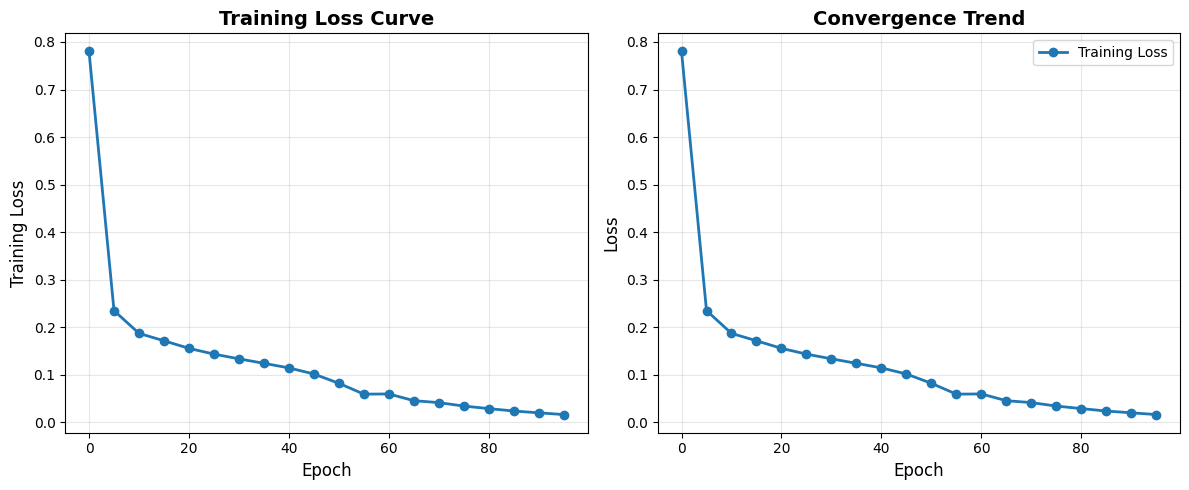


訓練統計：
初始 Loss: 0.7800
最終 Loss: 0.0166
Loss 下降: 0.7634 (97.9%)


In [90]:
# 畫 Training Loss 曲線
plt.figure(figsize=(12, 5))

# 圖1：Training Loss 曲線
plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, marker='o', linestyle='-', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 圖2：Loss 趨勢（平滑）
plt.subplot(1, 2, 2)
plt.plot(epochs_list, train_losses, marker='o', linestyle='-', linewidth=2, markersize=6, label='Training Loss')
# 可以在此處添加驗證 loss（如果需要）
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Convergence Trend', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印統計信息
print(f"\n訓練統計：")
print(f"初始 Loss: {train_losses[0]:.4f}")
print(f"最終 Loss: {train_losses[-1]:.4f}")
print(f"Loss 下降: {train_losses[0] - train_losses[-1]:.4f} ({(1 - train_losses[-1]/train_losses[0])*100:.1f}%)")